### Imports

In [2]:
import os
import random
import pickle
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import LabelEncoder
from sklearn.utils import class_weight
from sklearn.metrics import confusion_matrix, classification_report

import cv2
import tensorflow as tf
from tensorflow.keras import layers, Model
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.applications.efficientnet_v2 import preprocess_input


In [3]:
DATASET_ROOT = Path("/kaggle/input/full-pharaohs-augmented-dataset")

train_dir = DATASET_ROOT / "augmented_train"
val_dir   = DATASET_ROOT / "complete_valid_dataset"
test_dir  = DATASET_ROOT / "complete_test_dataset"

print("Train dir:", train_dir)
print("Val dir  :", val_dir)
print("Test dir :", test_dir)

Train dir: /kaggle/input/full-pharaohs-augmented-dataset/augmented_train
Val dir  : /kaggle/input/full-pharaohs-augmented-dataset/complete_valid_dataset
Test dir : /kaggle/input/full-pharaohs-augmented-dataset/complete_test_dataset


### Helper Functions

In [4]:
IMG_EXTS = {".jpg", ".jpeg"}  

def list_subdirs(path: Path):
    return sorted([p for p in path.iterdir() if p.is_dir()])

def make_df(root: Path):
    rows = []
    for class_dir in list_subdirs(root):
        label = class_dir.name
        for p in class_dir.iterdir():
            if p.is_file() and p.suffix.lower() in IMG_EXTS:
                rows.append({"label": label, "path": str(p)})
    return pd.DataFrame(rows, columns=["label", "path"])

def count_images_recursive(folder: Path):
    return sum(1 for p in folder.rglob("*") if p.is_file() and p.suffix.lower() in IMG_EXTS)

def count_per_class(root: Path, classes):
    out = {}
    for c in classes:
        out[c] = sum(1 for p in (root / c).iterdir() if p.is_file() and p.suffix.lower() in IMG_EXTS)
    return out


In [5]:
train_df = make_df(train_dir)
val_df   = make_df(val_dir)
test_df  = make_df(test_dir)

print("Train df:", train_df.shape)
print("Val df  :", val_df.shape)
print("Test df :", test_df.shape)

Train df: (22889, 2)
Val df  : (1543, 2)
Test df : (662, 2)


In [6]:
# classes from train 
classes = sorted(train_df["label"].unique().tolist())
print("Number of classes:", len(classes))
print("Sample classes:", classes[:10])

# sanity: same class set in val/test
print("Val classes match train:",  set(val_df["label"].unique()) == set(classes))
print("Test classes match train:", set(test_df["label"].unique()) == set(classes))

Number of classes: 96
Sample classes: ['Achoris', 'Ahmose_I', 'Akhenaton', 'Alexander_the_Great', 'Amasis_II', 'Amenemhat_I', 'Amenemhat_III', 'Amenhotep_II', 'Amenhotep_III', 'Amenhotep_III_and_God_Re-Horakhty']
Val classes match train: True
Test classes match train: True


In [7]:
print("Train images:", count_images_recursive(train_dir))
print("Val images  :", count_images_recursive(val_dir))
print("Test images :", count_images_recursive(test_dir))


Train images: 22889
Val images  : 1543
Test images : 662


### EDA

#### Class Imbalance

In [8]:
train_counts = count_per_class(train_dir, classes)
val_counts   = count_per_class(val_dir, classes)

train_vals = np.array([train_counts[c] for c in classes])
val_vals   = np.array([val_counts[c] for c in classes])

In [9]:
print("Train min/max:", train_vals.min(), train_vals.max(),
      "\nratio:", train_vals.max() / max(1, train_vals.min()))
print("Val   min/max:", val_vals.min(), val_vals.max())

Train min/max: 144 540 
ratio: 3.75
Val   min/max: 4 94


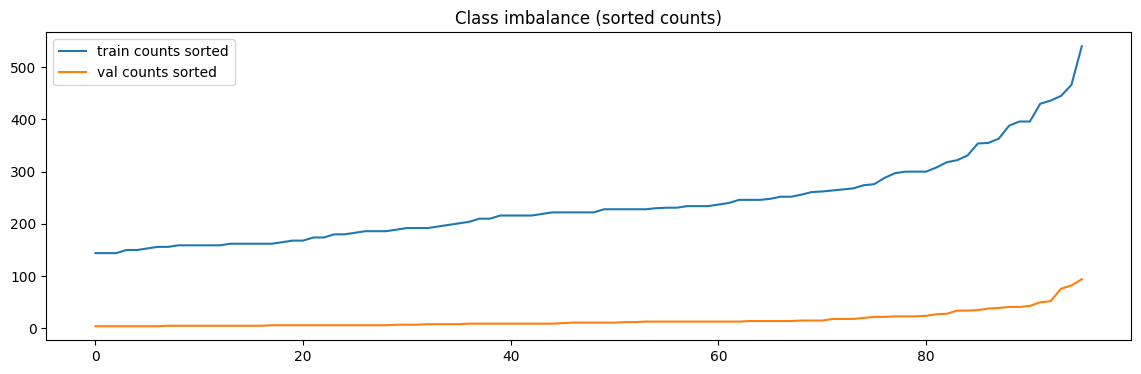

In [10]:
plt.figure(figsize=(14,4))
plt.plot(sorted(train_vals), label="train counts sorted")
plt.plot(sorted(val_vals), label="val counts sorted")
plt.legend()
plt.title("Class imbalance (sorted counts)")
plt.show()

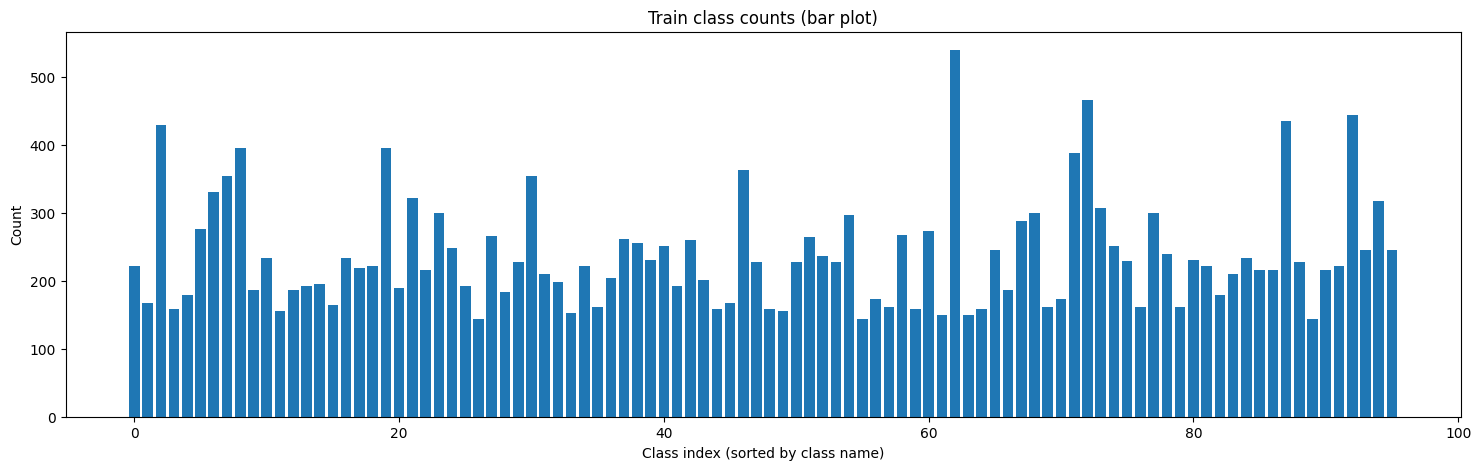

In [11]:
plt.figure(figsize=(18, 5))
plt.bar(range(len(classes)), train_vals)
plt.title("Train class counts (bar plot)")
plt.xlabel("Class index (sorted by class name)")
plt.ylabel("Count")
plt.show()

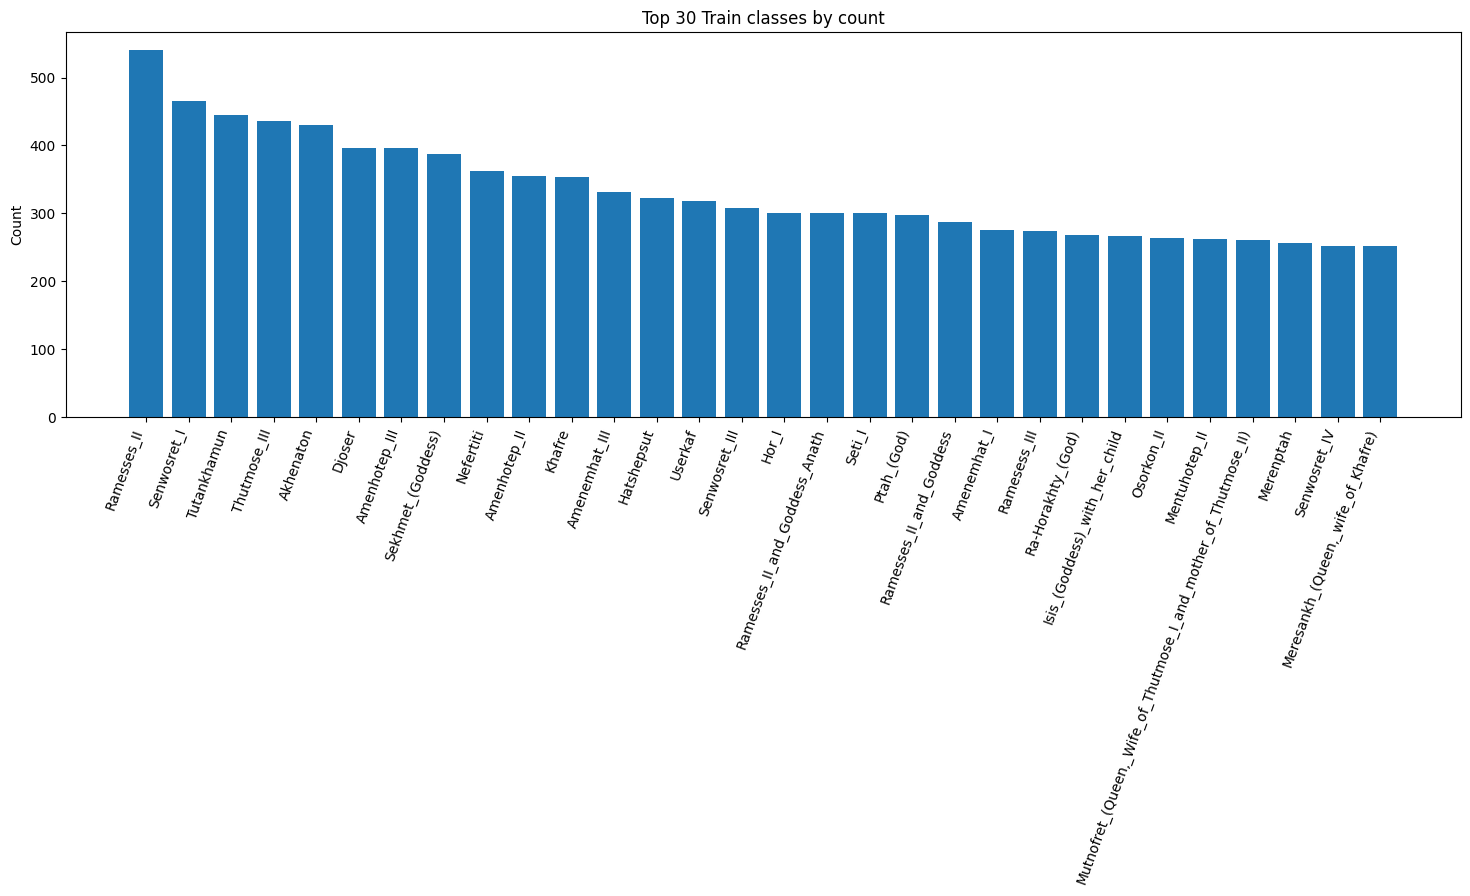

In [12]:
# plot top-30 most frequent
top_k = 30
sorted_idx = np.argsort(-train_vals)[:top_k]
plt.figure(figsize=(18, 5))
plt.bar([classes[i] for i in sorted_idx], train_vals[sorted_idx])
plt.title(f"Top {top_k} Train classes by count")
plt.xticks(rotation=70, ha="right")
plt.ylabel("Count")
plt.show()

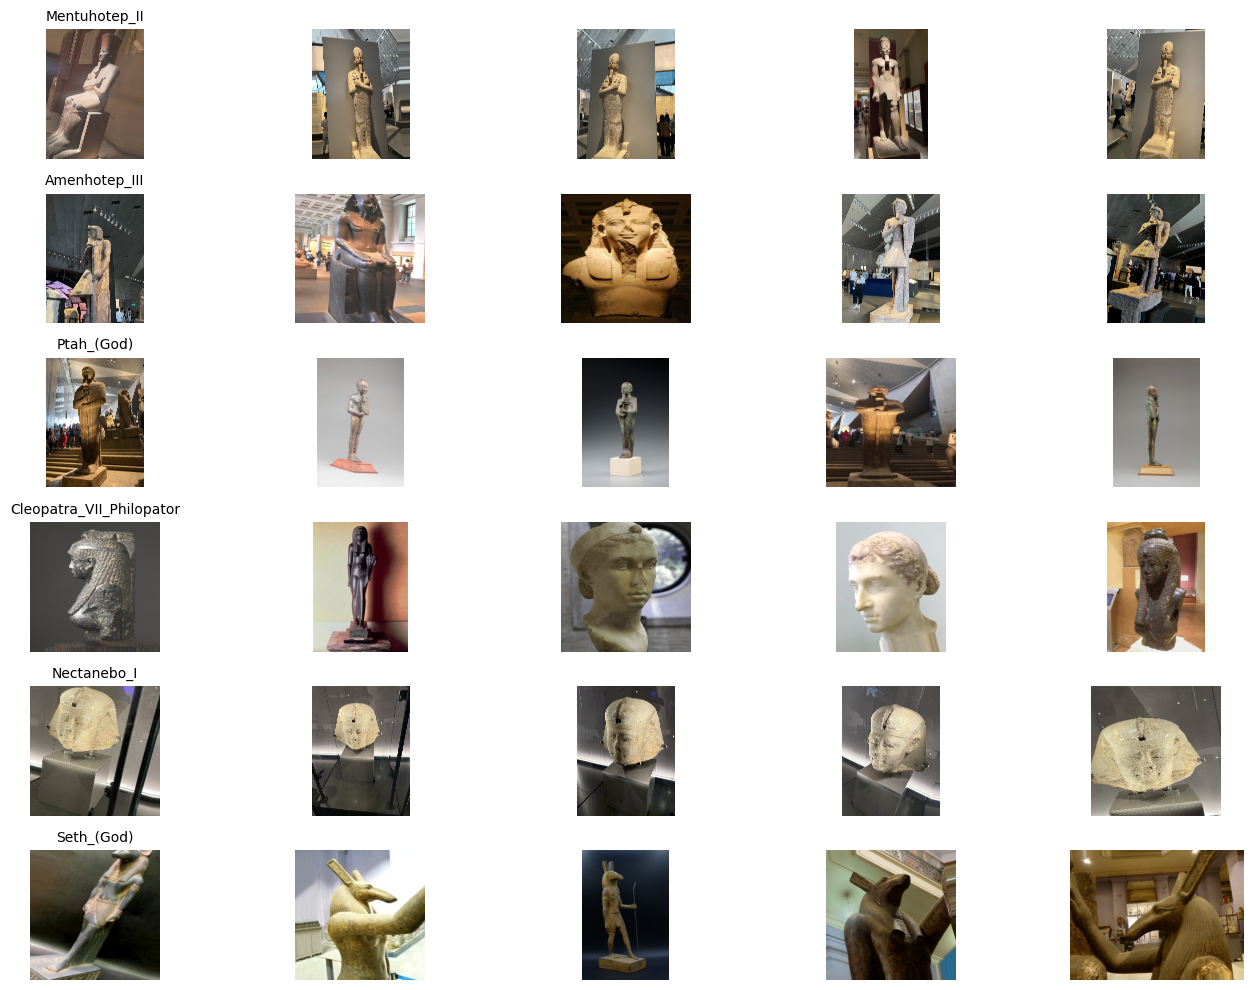

In [13]:
def show_samples_per_class(root: Path, class_names, k=5, rows=6):
    plt.figure(figsize=(14, 10))
    shown = 0
    picked = random.sample(class_names, min(len(class_names), rows))

    for cls in picked:
        imgs = [p for p in (root/cls).iterdir() if p.is_file() and p.suffix.lower() in IMG_EXTS]
        if not imgs:
            continue
        for i in range(min(k, len(imgs))):
            img_path = str(random.choice(imgs))
            img = tf.keras.utils.load_img(img_path)
            ax = plt.subplot(rows, k, shown + 1)
            plt.imshow(img)
            plt.axis("off")
            if i == 0:
                ax.set_title(cls, fontsize=10)
            shown += 1
            if shown >= rows * k:
                break
        if shown >= rows * k:
            break

    plt.tight_layout()
    plt.show()

show_samples_per_class(train_dir, classes, k=5, rows=6)


### Pipeline

In [14]:
AUTOTUNE = tf.data.AUTOTUNE
IMG_SIZE = 320  # Try 320 (more details in statues)
BATCH_SIZE = 32 

#### Label Encoding

In [15]:
encoder = LabelEncoder()

train_df["label_enc"] = encoder.fit_transform(train_df["label"])
val_df["label_enc"]   = encoder.transform(val_df["label"])
test_df["label_enc"]  = encoder.transform(test_df["label"])

NUM_CLASSES = len(encoder.classes_)
print("NUM_CLASSES:", NUM_CLASSES)

NUM_CLASSES: 96


In [65]:
"""
with open("/kaggle/input/encoder/other/default/1/label_encoder_efficientnetb0_aug_150version_2StageTrain.pkl", "rb") as f:
    encoder = pickle.load(f)

train_df["label_enc"] = encoder.transform(train_df["label"])
val_df["label_enc"]   = encoder.transform(val_df["label"])
test_df["label_enc"]  = encoder.transform(test_df["label"])

NUM_CLASSES = len(encoder.classes_)
print("NUM_CLASSES:", NUM_CLASSES)
"""

NUM_CLASSES: 96


#### Class Weights

In [16]:
y_train = train_df["label_enc"].values
classes_int = np.unique(y_train)

cw = class_weight.compute_class_weight(
    class_weight="balanced",
    classes=classes_int,
    y=y_train)

In [17]:
cw

array([1.07399587, 1.41920883, 0.55448159, 1.4995414 , 1.32459491,
       0.86386624, 0.72032351, 0.67162559, 0.60208859, 1.28186604,
       1.01891916, 1.52837874, 1.28186604, 1.24180773, 1.22270299,
       1.44501263, 1.01891916, 1.08870814, 1.07399587, 0.60208859,
       1.26151896, 0.74045678, 1.10382909, 0.79475694, 0.96139953,
       1.24180773, 1.65574363, 0.89634242, 1.30288024, 1.04573282,
       0.67352283, 1.13536706, 1.20417719, 1.55834695, 1.07399587,
       1.47177212, 1.16876021, 0.91002704, 0.93135579, 1.03215188,
       0.94613922, 1.24180773, 0.91351373, 1.18620439, 1.4995414 ,
       1.41920883, 0.65682392, 1.04573282, 1.4995414 , 1.52837874,
       1.04573282, 0.90313289, 1.00602145, 1.04573282, 0.80278479,
       1.65574363, 1.37027059, 1.47177212, 0.8896533 , 1.4995414 ,
       0.87017184, 1.58951389, 0.44153164, 1.58951389, 1.4995414 ,
       0.96921579, 1.28186604, 0.82787182, 0.79475694, 1.47177212,
       1.37027059, 0.61450279, 0.5116461 , 0.77411391, 0.94613

In [18]:
cw_dict = {int(c): float(w) for c, w in zip(classes_int, cw)}

In [19]:
cw_dict

{0: 1.0739958708708708,
 1: 1.4192088293650793,
 2: 0.5544815891472868,
 3: 1.4995414046121593,
 4: 1.3245949074074075,
 5: 0.8638662439613527,
 6: 0.7203235146022156,
 7: 0.67162558685446,
 8: 0.6020885942760943,
 9: 1.2818660394265233,
 10: 1.0189191595441596,
 11: 1.5283787393162394,
 12: 1.2818660394265233,
 13: 1.2418077256944444,
 14: 1.2227029914529914,
 15: 1.4450126262626262,
 16: 1.0189191595441596,
 17: 1.0887081430745815,
 18: 1.0739958708708708,
 19: 0.6020885942760943,
 20: 1.2615189594356262,
 21: 0.7404567805383023,
 22: 1.1038290895061729,
 23: 0.7947569444444444,
 24: 0.9613995295698925,
 25: 1.2418077256944444,
 26: 1.6557436342592593,
 27: 0.8963424185463659,
 28: 1.3028802367941712,
 29: 1.0457328216374269,
 30: 0.673522834274953,
 31: 1.1353670634920634,
 32: 1.2041771885521886,
 33: 1.5583469498910676,
 34: 1.0739958708708708,
 35: 1.4717721193415638,
 36: 1.1687602124183007,
 37: 0.9100270356234097,
 38: 0.9313557942708334,
 39: 1.032151875901876,
 40: 0.9461392

In [21]:
cw_vec = np.zeros(NUM_CLASSES, dtype=np.float32)
for c, w in cw_dict.items():
    cw_vec[int(c)] = float(w)

cw_tf = tf.constant(cw_vec, dtype=tf.float32)
print("Example weights:", list(cw_dict.items())[:10])

Example weights: [(0, 1.0739958708708708), (1, 1.4192088293650793), (2, 0.5544815891472868), (3, 1.4995414046121593), (4, 1.3245949074074075), (5, 0.8638662439613527), (6, 0.7203235146022156), (7, 0.67162558685446), (8, 0.6020885942760943), (9, 1.2818660394265233)]


#### EfficientNet preprocessing

In [40]:
def preprocess_image(path: str, size=IMG_SIZE):
    img_bgr = cv2.imread(path)
    if img_bgr is None:
        raise ValueError(f"Could not read image: {path}")
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img_rgb, (size, size), interpolation=cv2.INTER_AREA)
    img = img.astype(np.float32)
    img = preprocess_input(img)   # EfficientNet preprocess_input
    return img


##### On-the-fly Augmentation

In [41]:
data_aug = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.05,fill_mode="reflect"),
    layers.RandomZoom(0.15),
    layers.RandomBrightness(0.1),
    layers.RandomContrast(0.1),
    layers.RandomTranslation(0.07, 0.07, fill_mode="reflect"),
], name="data_aug")

In [42]:
class TFDataset:
    def __init__(self, df, batch_size=BATCH_SIZE, shuffle=True, image_size=IMG_SIZE, augment=False):
        self.df = df.reset_index(drop=True)
        self.batch_size = batch_size
        self.shuffle = shuffle
        self.augment = augment
        self.image_size = image_size if isinstance(image_size, int) else image_size[0]
        self.dataset = self._build_dataset()

    def _load_and_preprocess(self, path, label):
        def _py_preprocess(path_str):
            path_str = path_str.decode("utf-8")
            img = preprocess_image(path_str, size=self.image_size)
            return img.astype("float32")

        img = tf.numpy_function(_py_preprocess, [path], tf.float32)
        img.set_shape((self.image_size, self.image_size, 3))
        label = tf.cast(label, tf.int32)   # keep integer label for now
        return img, label

    def _maybe_augment(self, img, label):
        if self.augment:
            img = data_aug(img, training=True)
        return img, label

    def _build_dataset(self):
        paths = self.df["path"].values
        labels = self.df["label_enc"].values.astype(np.int32)

        ds = tf.data.Dataset.from_tensor_slices((paths, labels))

        if self.shuffle:
            ds = ds.shuffle(buffer_size=len(self.df), reshuffle_each_iteration=True)

        ds = ds.map(self._load_and_preprocess, num_parallel_calls=AUTOTUNE)
        ds = ds.map(self._maybe_augment, num_parallel_calls=AUTOTUNE)
        ds = ds.batch(self.batch_size).prefetch(AUTOTUNE)
        return ds

    def __iter__(self):
        return iter(self.dataset)

    def __len__(self):
        return int(np.ceil(len(self.df) / self.batch_size))


In [43]:
train_ds = TFDataset(train_df, augment=True, shuffle=True).dataset
val_ds   = TFDataset(val_df,   augment=False, shuffle=False).dataset
test_ds  = TFDataset(test_df,  augment=False, shuffle=False).dataset

##### MixUp

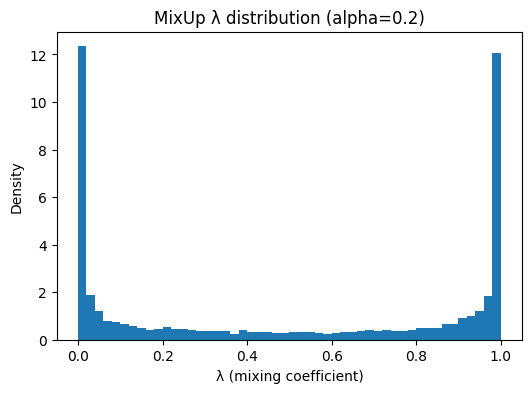

In [44]:
#  λ distribution
# plot to justify MixUp hyperparameter choice (α).
alpha = 0.2
N = 10000

lam = np.random.beta(alpha, alpha, N)

plt.figure(figsize=(6,4))
plt.hist(lam, bins=50, density=True)
plt.xlabel("λ (mixing coefficient)")
plt.ylabel("Density")
plt.title(f"MixUp λ distribution (alpha={alpha})")
plt.show()

In [45]:
MIXUP_ALPHA = 0.2
MIXUP_PROB  = 0.4

def _sample_beta(alpha, shape):
    g1 = tf.random.gamma(shape, alpha)
    g2 = tf.random.gamma(shape, alpha)
    return g1 / (g1 + g2)

def _to_onehot(labels_int):
    return tf.one_hot(labels_int, NUM_CLASSES, dtype=tf.float32)

def _sample_weight_from_onehot(y_onehot):
    # expected weight per sample: sum_j y_j * w_j
    return tf.reduce_sum(y_onehot * cw_tf[None, :], axis=1)  # (B,)


In [46]:
def mixup_batch(images, labels_int):
    B = tf.shape(images)[0]
    y1 = _to_onehot(labels_int)

    idx = tf.random.shuffle(tf.range(B))
    x2 = tf.gather(images, idx)
    y2 = tf.gather(y1, idx)

    lam = _sample_beta(MIXUP_ALPHA, [B])
    lam_x = tf.reshape(lam, [B, 1, 1, 1])
    lam_y = tf.reshape(lam, [B, 1])

    x = images * lam_x + x2 * (1.0 - lam_x)
    y = y1 * lam_y + y2 * (1.0 - lam_y)

    sw = _sample_weight_from_onehot(y)
    return x, y, sw

def plain_batch_train(images, labels_int):
    y = _to_onehot(labels_int)
    sw = _sample_weight_from_onehot(y)
    return images, y, sw

def maybe_mixup(images, labels_int):
    do = tf.random.uniform([]) < MIXUP_PROB
    return tf.cond(
        do,
        lambda: mixup_batch(images, labels_int),
        lambda: plain_batch_train(images, labels_int),
    )

def plain_batch_eval(images, labels_int):
    y = _to_onehot(labels_int)
    return images, y

In [47]:
# Train: MixUp + weights
train_ds = (
    train_ds
    .map(maybe_mixup, num_parallel_calls=AUTOTUNE)
    .prefetch(AUTOTUNE)
)

# Val/Test: no MixUp, but convert to onehot 
val_ds = (
    val_ds
    .map(plain_batch_eval, num_parallel_calls=AUTOTUNE)
    .prefetch(AUTOTUNE)
)

test_ds = (
    test_ds
    .map(plain_batch_eval, num_parallel_calls=AUTOTUNE)
    .prefetch(AUTOTUNE)
)


#### Model

In [48]:
# try EfficientNetV2S (usually noticeably better)
base = tf.keras.applications.EfficientNetV2B0(
    include_top=False,
    weights="imagenet",
    input_shape=(IMG_SIZE, IMG_SIZE, 3)
)

In [49]:
def build_model(base,img_size=IMG_SIZE, dropout=0.3):
    inputs = layers.Input(shape=(img_size, img_size, 3))
    x = base(inputs, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(512, kernel_regularizer=tf.keras.regularizers.l2(1e-4), use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation("relu")(x)
    x = layers.Dropout(dropout)(x)
    x = layers.Dense(256, kernel_regularizer=tf.keras.regularizers.l2(1e-4), use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation("relu")(x)
    x = layers.Dropout(dropout*0.7)(x)
    outputs = layers.Dense(NUM_CLASSES, activation="softmax", dtype="float32")(x)
    model = Model(inputs, outputs)
    
    return model


#### Training Stage 1: Train head only (freeze backbone)

In [50]:
# Stage 1: freeze base
base.trainable = False
model = build_model(base, IMG_SIZE, dropout=0.25)
model.summary()

Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_5 (InputLayer)      │ (None, 320, 320, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetv2-b0 (Functional)  │ (None, 10, 10, 1280)   │     5,919,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 512)            │       655,360 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 256)            │       131,072 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 96)             │        24,672 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,733,488 (25.69 MB)

 Trainable params: 812,640 (3.10 MB)

 Non-trainable params: 5,920,848 (22.59 MB)

In [51]:
EPOCHS_STAGE1 = 20

In [52]:
print(train_ds.element_spec)
print(val_ds.element_spec)
print(test_ds.element_spec)


(TensorSpec(shape=(None, 320, 320, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None, 96), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.float32, name=None))
(TensorSpec(shape=(None, 320, 320, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None, 96), dtype=tf.float32, name=None))
(TensorSpec(shape=(None, 320, 320, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None, 96), dtype=tf.float32, name=None))


In [53]:
# stabilizes training before fine-tuning
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4), 
    loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.05),
    metrics=["categorical_accuracy"]
)

early_stop = EarlyStopping(monitor="val_loss", patience=4, restore_best_weights=True)
reduce_lr  = ReduceLROnPlateau(monitor="val_loss", factor=0.3, patience=2, min_lr=1e-6, verbose=1)

history1 = model.fit(
    train_ds,                   
    validation_data=val_ds,
    epochs=EPOCHS_STAGE1,
    callbacks=[early_stop, reduce_lr]
)


Epoch 1/20
716/716 ━━━━━━━━━━━━━━━━━━━━ 1178s 2s/step - categorical_accuracy: 0.1713 - loss: 4.1412 - val_categorical_accuracy: 0.6241 - val_loss: 2.3528 - learning_rate: 1.0000e-04
Epoch 2/20
716/716 ━━━━━━━━━━━━━━━━━━━━ 1172s 2s/step - categorical_accuracy: 0.6214 - loss: 2.3345 - val_categorical_accuracy: 0.7576 - val_loss: 1.6463 - learning_rate: 1.0000e-04
Epoch 3/20
716/716 ━━━━━━━━━━━━━━━━━━━━ 1129s 2s/step - categorical_accuracy: 0.7486 - loss: 1.7531 - val_categorical_accuracy: 0.8471 - val_loss: 1.2860 - learning_rate: 1.0000e-04
Epoch 4/20
716/716 ━━━━━━━━━━━━━━━━━━━━ 1140s 2s/step - categorical_accuracy: 0.8164 - loss: 1.4859 - val_categorical_accuracy: 0.8827 - val_loss: 1.1091 - learning_rate: 1.0000e-04
Epoch 5/20
716/716 ━━━━━━━━━━━━━━━━━━━━ 1304s 2s/step - categorical_accuracy: 0.8468 - loss: 1.3613 - val_categorical_accuracy: 0.9138 - val_loss: 0.9997 - learning_rate: 1.0000e-04
Epoch 6/20
716/716 ━━━━━━━━━━━━━━━━━━━━ 1248s 2s/step - categorical_accuracy: 0.8776 - los

In [54]:
model.save("/kaggle/working/3RDTRIAL_11kVersion_EfficientNetV2B0_withMixUp_head.keras")

#### Training Stage 2: Fine-tuning (unfreeze last blocks)

In [82]:
#model = tf.keras.models.load_model("/kaggle/input/11kheadmodel/keras/default/1/11kVersion_EfficientNetV2B0_withMixUp_head.keras")

In [55]:
EPOCHS_STAGE2 = 15
UNFREEZE_LAST_N = int( len(base.layers) * 0.3) 

In [56]:
print("Total layers:", len(base.layers))
print("Unfreezing last:", UNFREEZE_LAST_N)

Total layers: 270
Unfreezing last: 81


In [57]:
base.trainable = True

# freeze all but last N layers 
for layer in base.layers[:-UNFREEZE_LAST_N]:
    layer.trainable = False

# keep BatchNorm frozen
for layer in base.layers[-UNFREEZE_LAST_N:]:
    if isinstance(layer, layers.BatchNormalization):
        layer.trainable = False
    else:
        layer.trainable = True


In [58]:
# lower LR for fine-tuning
model.compile(
    optimizer=tf.keras.optimizers.AdamW(learning_rate=3e-5, weight_decay=1e-5),
    loss=tf.keras.losses.CategoricalCrossentropy(),
    metrics=["categorical_accuracy"]
)

early_stop2 = EarlyStopping(monitor="val_loss", patience=4, restore_best_weights=True)
reduce_lr2  = ReduceLROnPlateau(monitor="val_loss", factor=0.3, patience=2, min_lr=1e-6, verbose=1)

history2 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS_STAGE2,
    callbacks=[early_stop2, reduce_lr2]
)

Epoch 1/15


2026-01-31 20:12:36.077118: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-01-31 20:12:36.279726: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


715/716 ━━━━━━━━━━━━━━━━━━━━ 1s 2s/step - categorical_accuracy: 0.9547 - loss: 0.5608

2026-01-31 20:31:05.412629: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-01-31 20:31:05.617264: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


716/716 ━━━━━━━━━━━━━━━━━━━━ 1235s 2s/step - categorical_accuracy: 0.9548 - loss: 0.5608 - val_categorical_accuracy: 0.9669 - val_loss: 0.2678 - learning_rate: 3.0000e-05
Epoch 2/15
716/716 ━━━━━━━━━━━━━━━━━━━━ 1160s 2s/step - categorical_accuracy: 0.9687 - loss: 0.4591 - val_categorical_accuracy: 0.9702 - val_loss: 0.2545 - learning_rate: 3.0000e-05
Epoch 3/15
716/716 ━━━━━━━━━━━━━━━━━━━━ 1138s 2s/step - categorical_accuracy: 0.9683 - loss: 0.4872 - val_categorical_accuracy: 0.9708 - val_loss: 0.2426 - learning_rate: 3.0000e-05
Epoch 4/15
716/716 ━━━━━━━━━━━━━━━━━━━━ 1131s 2s/step - categorical_accuracy: 0.9697 - loss: 0.4709 - val_categorical_accuracy: 0.9721 - val_loss: 0.2370 - learning_rate: 3.0000e-05
Epoch 5/15
716/716 ━━━━━━━━━━━━━━━━━━━━ 1150s 2s/step - categorical_accuracy: 0.9740 - loss: 0.4412 - val_categorical_accuracy: 0.9728 - val_loss: 0.2323 - learning_rate: 3.0000e-05
Epoch 6/15
716/716 ━━━━━━━━━━━━━━━━━━━━ 1130s 2s/step - categorical_accuracy: 0.9729 - loss: 0.4529 -

In [71]:
model.save("/kaggle/working/3RD_TRIAL_11kVersion_EfficientNetV2B0_withMixUp_layersStage2.keras")

### Results 

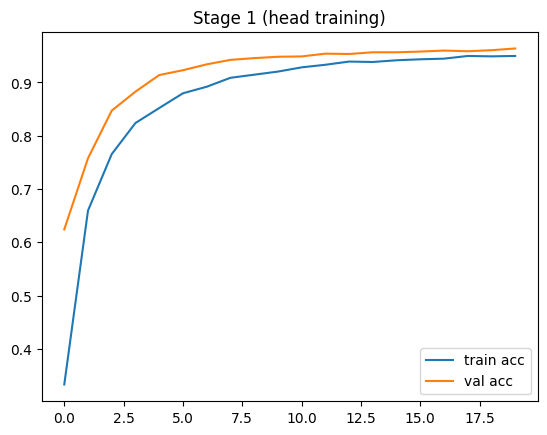

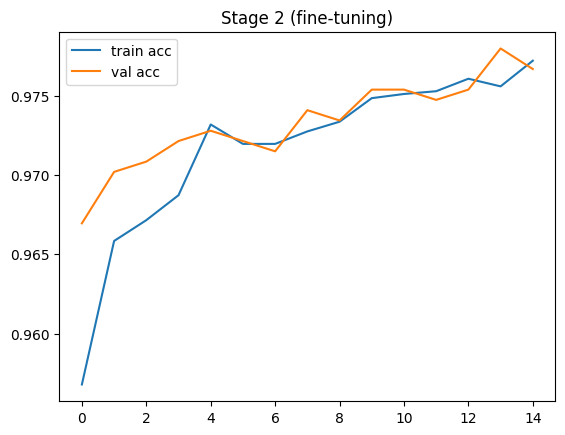

In [60]:
def plot_history(h, title):
    plt.figure()
    plt.plot(h.history["categorical_accuracy"], label="train acc")
    plt.plot(h.history["val_categorical_accuracy"], label="val acc")
    plt.title(title)
    plt.legend()
    plt.show()

plot_history(history1, "Stage 1 (head training)")
plot_history(history2, "Stage 2 (fine-tuning)")

In [61]:
print(history2.history.keys())

dict_keys(['categorical_accuracy', 'loss', 'val_categorical_accuracy', 'val_loss', 'learning_rate'])


In [74]:
final_train_loss = history2.history["loss"][-1]
final_val_loss   = history2.history["val_loss"][-1]

final_train_acc = history2.history["categorical_accuracy"][-1]
final_val_acc   = history2.history["val_categorical_accuracy"][-1]

print("Final Train accuracy: ", final_train_acc * 100)
print("Final Train loss: ", final_train_loss)
print("Final Validation accuracy: ", final_val_acc * 100)
print("Final Validation loss: ", final_val_loss)


Final Train accuracy:  97.71943092346191
Final Train loss:  0.4221457242965698
Final Validation accuracy:  97.66688346862793
Final Validation loss:  0.2065100222826004


#### Confusion matrix + classification report

In [73]:
y_true, y_pred = [], []

for xb, yb in val_ds:
    preds = model.predict(xb, verbose=0)           # (B, num_classes)
    y_pred.extend(np.argmax(preds, axis=1).tolist())

    yb_np = yb.numpy()

    # If y is one-hot (B, C) -> convert to class id (B,)
    if yb_np.ndim > 1 and yb_np.shape[-1] > 1:
        yb_np = np.argmax(yb_np, axis=1)

    y_true.extend(yb_np.astype(int).tolist())

y_true = np.array(y_true)
y_pred = np.array(y_pred)

cm = confusion_matrix(y_true, y_pred, labels=np.arange(len(classes)))
print("Val accuracy:", (y_true == y_pred).mean())

print("\nClassification report (per-class):")
print(classification_report(y_true, y_pred,labels=np.arange(len(classes)),target_names=classes,digits=4))


Val accuracy: 0.9779650032404407

Classification report (per-class):
                                                                   precision    recall  f1-score   support

                                                          Achoris     1.0000    1.0000    1.0000        13
                                                         Ahmose_I     0.8333    1.0000    0.9091         5
                                                        Akhenaton     0.9800    0.9800    0.9800        50
                                              Alexander_the_Great     0.7500    0.6667    0.7059         9
                                                        Amasis_II     0.8333    1.0000    0.9091         5
                                                      Amenemhat_I     1.0000    1.0000    1.0000         8
                                                    Amenemhat_III     1.0000    0.9487    0.9737        39
                                                     Amenhotep_II     1.00

#### confusion matrix for most confused classes

In [75]:
support = cm.sum(axis=1)          # number of true samples per class
cm_norm = cm / support[:, None]  # row-normalized confusion rates
confusions = []

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        if i != j and cm[i, j] > 0:
            confusions.append((
                cm[i, j],           # count
                cm_norm[i, j],      # rate
                classes[i],         # true
                classes[j]          # predicted
            ))


confusions.sort(reverse=True)       #sorted by count

print("Top confusions:")
for count, rate, true, pred in confusions[:15]:
    print(f"{true} -> {pred} : {count} ({rate*100:.2f}%)")


Top confusions:
Ptah_(God) -> Sekhmet_(Goddess) : 2 (11.11%)
Senwosret_I -> Mentuhotep_II : 2 (2.44%)
Ptolemy_I_Soter -> Alexander_the_Great : 1 (25.00%)
Isis_(Goddess) -> Hathor_(Goddess) : 1 (25.00%)
Shepsekaf -> Userkaf : 1 (20.00%)
Seth_(God) -> Horus_(God) : 1 (20.00%)
Mut_(Goddess) -> Amasis_II : 1 (16.67%)
Menkaure_and_his_wife_(likely_Queen_Khamerernebty_II) -> Ramesses_II_and_God_Ptah_and_Goddess_Sekhment : 1 (16.67%)
Arsinoe_III_(Queen,_daughter_of_Ptolemy_I_and_wife_of_Ptolemy_II) -> Alexander_the_Great : 1 (16.67%)
Amun_(God) -> Userkaf : 1 (16.67%)
Amun_(God) -> Sekhmet_(Goddess) : 1 (16.67%)
Amun_(God) -> Nofret_(Queen,_possibly_Nofret_II,_wife_of_Senusret_II) : 1 (16.67%)
Alexander_the_Great -> Ptolemy_II_Philadelphus : 1 (11.11%)
Alexander_the_Great -> Khafre : 1 (11.11%)
Alexander_the_Great -> Arsinoe_II_(Queen,_sister_and_wife_of_Ptolemy_IV) : 1 (11.11%)


In [76]:
support = cm.sum(axis=1)
cm_norm = cm / support[:, None]

print("All confusions (non-zero):")
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        if i != j and cm[i, j] > 0:
            print(
                f"{classes[i]} → {classes[j]} : "
                f"{cm[i,j]}/{support[i]} "
                f"({cm_norm[i,j]*100:.2f}%)"
            )


All confusions (non-zero):
Akhenaton → Ramesses_II : 1/50 (2.00%)
Alexander_the_Great → Arsinoe_II_(Queen,_sister_and_wife_of_Ptolemy_IV) : 1/9 (11.11%)
Alexander_the_Great → Khafre : 1/9 (11.11%)
Alexander_the_Great → Ptolemy_II_Philadelphus : 1/9 (11.11%)
Amenemhat_III → Cleopatra_VII_Philopator : 1/39 (2.56%)
Amenemhat_III → Thutmose_III : 1/39 (2.56%)
Amun_(God) → Nofret_(Queen,_possibly_Nofret_II,_wife_of_Senusret_II) : 1/6 (16.67%)
Amun_(God) → Sekhmet_(Goddess) : 1/6 (16.67%)
Amun_(God) → Userkaf : 1/6 (16.67%)
Arsinoe_III_(Queen,_daughter_of_Ptolemy_I_and_wife_of_Ptolemy_II) → Alexander_the_Great : 1/6 (16.67%)
Hatshepsut → Ramesses_II : 1/38 (2.63%)
Isis_(Goddess) → Hathor_(Goddess) : 1/4 (25.00%)
Menkaure_and_his_wife_(likely_Queen_Khamerernebty_II) → Ramesses_II_and_God_Ptah_and_Goddess_Sekhment : 1/6 (16.67%)
Mut_(Goddess) → Amasis_II : 1/6 (16.67%)
Mutnofret_(Queen,_Wife_of_Thutmose_I_and_mother_of_Thutmose_II) → Sekhmet_(Goddess) : 1/15 (6.67%)
Pepi_I → Ptolemy_II_Philade

### Test Inference

In [77]:
# predictions
y_prob = model.predict(test_ds, verbose=1)
y_pred = np.argmax(y_prob, axis=1)

# true labels (currently one-hot)
y_true_oh = np.concatenate([y.numpy() for _, y in test_ds], axis=0)
y_true = np.argmax(y_true_oh, axis=1)

# accuracy
test_acc = (y_true == y_pred).mean()
print(f"Test accuracy: {test_acc:.4f}")

# report
print(classification_report(y_true, y_pred, target_names=encoder.classes_))

cm_test = confusion_matrix(y_true, y_pred)
print("Confusion matrix shape:", cm_test.shape)
print("\nConfusion Matrix:\n", cm_test)

21/21 ━━━━━━━━━━━━━━━━━━━━ 28s 1s/step
Test accuracy: 0.9683
                                                                   precision    recall  f1-score   support

                                                          Achoris       1.00      1.00      1.00         6
                                                         Ahmose_I       1.00      1.00      1.00         2
                                                        Akhenaton       1.00      0.95      0.98        22
                                              Alexander_the_Great       1.00      1.00      1.00         4
                                                        Amasis_II       0.67      1.00      0.80         2
                                                      Amenemhat_I       1.00      1.00      1.00         4
                                                    Amenemhat_III       1.00      1.00      1.00        16
                                                     Amenhotep_II       1.00      

In [78]:
print(f"Test accuracy: {test_acc*100:.4f}")

Test accuracy: 96.8278


In [79]:
support_test = cm_test.sum(axis=1)
cm_norm_test = cm_test / support_test[:, None]

print("All confusions (non-zero):")
for i in range(cm_test.shape[0]):
    for j in range(cm_test.shape[1]):
        if i != j and cm_test[i, j] > 0:
            print(
                f"{classes[i]} → {classes[j]} : "
                f"{cm_test[i,j]}/{support_test[i]} "
                f"({cm_norm_test[i,j]*100:.2f}%)"
            )


All confusions (non-zero):
Akhenaton → Djoser : 1/22 (4.55%)
Amenhotep_II → Amasis_II : 1/18 (5.56%)
Amenhotep_III → Thutmose_III : 1/15 (6.67%)
Hathor_(Goddess) → Senwosret_III : 1/5 (20.00%)
Hathor_(Goddess) → Yuya_(father_of_Queen_Tiye) : 1/5 (20.00%)
Hatshepsut → Ramesses_II : 1/16 (6.25%)
Khasekhem → Sobekhotep_V : 1/2 (50.00%)
Neferkare_Shabaka → Senwosret_III : 1/2 (50.00%)
Ptolemy_II_Philadelphus → Arsinoe_II_(Queen,_sister_and_wife_of_Ptolemy_IV) : 1/2 (50.00%)
Ramesses_II → Sobekemsaf_I : 1/41 (2.44%)
Senwosret_I → Mentuhotep_II : 2/35 (5.71%)
Senwosret_I → Senwosret_IV : 1/35 (2.86%)
Senwosret_III → Amenhotep_III : 1/11 (9.09%)
Sobekhotep_V → Mentuhotep_II : 1/6 (16.67%)
Thutmose_III → Amenhotep_III : 1/33 (3.03%)
Thutmose_III → Hatshepsut : 1/33 (3.03%)
Thutmose_III → Senwosret_I : 2/33 (6.06%)
Thutmose_IV → Cleopatra_VII_Philopator : 1/3 (33.33%)
Tiye_(Queen,_wife_of_Amenhotep_III) → Amenhotep_III_and_Wife_Queen_Tiye : 1/3 (33.33%)


In [80]:
#sorted by rate
support_test = cm_test.sum(axis=1)
cm_norm_test = cm_test / support_test[:, None]
all_confusions_test =[]

print("All confusions (non-zero):")
for i in range(cm_test.shape[0]):
    for j in range(cm_test.shape[1]):
        if i != j and cm_test[i, j] > 0:
           all_confusions_test.append((cm_norm_test[i,j], cm_test[i,j], classes[i], classes[j]))

all_confusions_test.sort(reverse=True) # sorts by rate first

print("Top confusions by RATE:")
for rate, count, true, pred in all_confusions_test:
    print(f"{true} → {pred} :  {count}/{support_test[classes.index(true)]} ({rate*100:.2f}%)")

All confusions (non-zero):
Top confusions by RATE:
Ptolemy_II_Philadelphus → Arsinoe_II_(Queen,_sister_and_wife_of_Ptolemy_IV) :  1/2 (50.00%)
Neferkare_Shabaka → Senwosret_III :  1/2 (50.00%)
Khasekhem → Sobekhotep_V :  1/2 (50.00%)
Tiye_(Queen,_wife_of_Amenhotep_III) → Amenhotep_III_and_Wife_Queen_Tiye :  1/3 (33.33%)
Thutmose_IV → Cleopatra_VII_Philopator :  1/3 (33.33%)
Hathor_(Goddess) → Yuya_(father_of_Queen_Tiye) :  1/5 (20.00%)
Hathor_(Goddess) → Senwosret_III :  1/5 (20.00%)
Sobekhotep_V → Mentuhotep_II :  1/6 (16.67%)
Senwosret_III → Amenhotep_III :  1/11 (9.09%)
Amenhotep_III → Thutmose_III :  1/15 (6.67%)
Hatshepsut → Ramesses_II :  1/16 (6.25%)
Thutmose_III → Senwosret_I :  2/33 (6.06%)
Senwosret_I → Mentuhotep_II :  2/35 (5.71%)
Amenhotep_II → Amasis_II :  1/18 (5.56%)
Akhenaton → Djoser :  1/22 (4.55%)
Thutmose_III → Hatshepsut :  1/33 (3.03%)
Thutmose_III → Amenhotep_III :  1/33 (3.03%)
Senwosret_I → Senwosret_IV :  1/35 (2.86%)
Ramesses_II → Sobekemsaf_I :  1/41 (2.44%

### Save Outputs

In [111]:
"""
# Save final model
model.save("efficientb0_aug_150version_2stagetrain.keras")

with open("/kaggle/working/label_encoder_efficientnetb0_aug_150version_2StageTrain.pkl", "wb") as f:
    pickle.dump(encoder, f)
    """

In [ ]:
with open("/kaggle/working/label_encoder_efficientnetb0_aug_3RDTRIAL_11kversion_2StageTrain.pkl", "wb") as f:
    pickle.dump(encoder, f)